In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from gbeampro import (
    GaussBeam, OpticalSystem,
    Propagation, ThinLens,
    Interface, InterfaceCurved,
    CurvedMirrorTan, CurvedMirrorSag,
)
import gbeampro.plot as gplot
import gbeampro.analysis as ga
import gbeampro
print('gbeampro version:', gbeampro.__version__)

gbeampro version: 2.0.0


## Propagation

OpticalSystem trace  [wl=1.064 um]
   #  Type                   z (mm)     w (um)      R (mm)   th (urad)
------------------------------------------------------------------------
   0  --- input ---           0.000    1000.00         inf      338.68
   1  Propagation           300.000    1005.15   2.936e+04      336.95


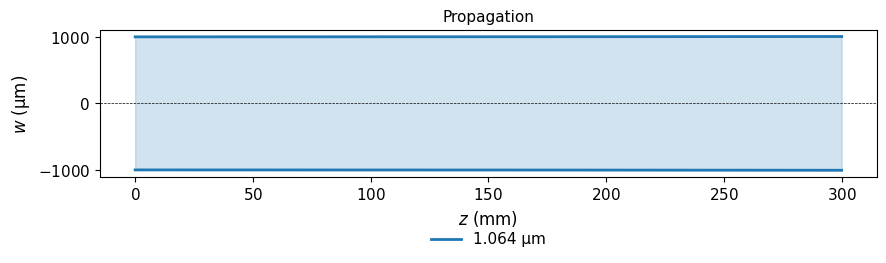

In [2]:
beam = GaussBeam.from_waist(wl_um=1.064, w0_mm=1.0)
sys = OpticalSystem().add(Propagation(300))
traj = sys.trace(beam, dz=1.0)
print(sys.summary(beam))

fig, ax = plt.subplots(figsize=(9, 3))
gplot.plot_system(sys, traj, ax, label='1.064 µm')
ax.set_title('Propagation')
plt.tight_layout()

## ThinLens

OpticalSystem trace  [wl=1.064 um]
   #  Type                   z (mm)     w (um)      R (mm)   th (urad)
------------------------------------------------------------------------
   0  --- input ---           0.000    1000.00         inf      338.68
   1  Propagation           100.000    1000.57   8.728e+04      338.49
   2  ThinLens              100.000    1000.57  -5.003e+01      338.49
   3  Propagation           200.000    1000.00   5.000e+01      338.68
Beam waists:  z=150.020 mm (2w0=33.9 um)


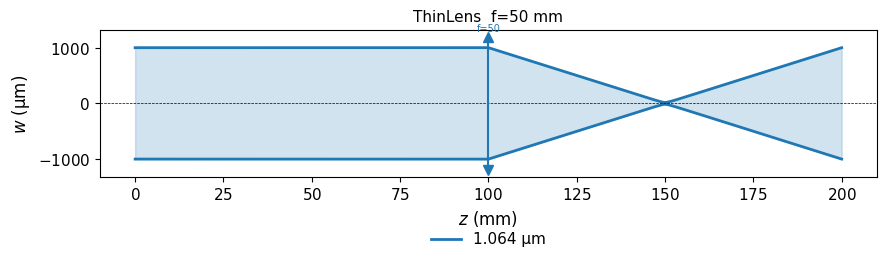

In [3]:
beam = GaussBeam.from_waist(wl_um=1.064, w0_mm=1.0)
sys = (OpticalSystem()
       .add(Propagation(100))
       .add(ThinLens(f_mm=50))
       .add(Propagation(100)))
traj = sys.trace(beam, dz=0.5)
print(sys.summary(beam))

fig, ax = plt.subplots(figsize=(9, 3))
gplot.plot_system(sys, traj, ax, label='1.064 µm')
ax.set_title('ThinLens  f=50 mm')
plt.tight_layout()

## Interface (flat, n1→n2)

OpticalSystem trace  [wl=1.064 um]
   #  Type                   z (mm)     w (um)      R (mm)   th (urad)
------------------------------------------------------------------------
   0  --- input ---           0.000    1000.00         inf      338.68
   1  Propagation            50.000    1000.14   1.744e+05      338.63
   2  ThinLens               50.000    1000.14  -1.001e+02      338.63
   3  Propagation           140.000     105.05  -1.110e+01     3224.04
   4  Interface             140.000     105.05  -1.775e+01     2015.03
   5  Propagation           170.000      94.37   1.617e+01     2243.02
   6  Interface             170.000      94.37   1.011e+01     3588.82
   7  Propagation           250.000     888.85   8.894e+01      381.04
Beam waists:  z=155.910 mm (2w0=67.7 um)


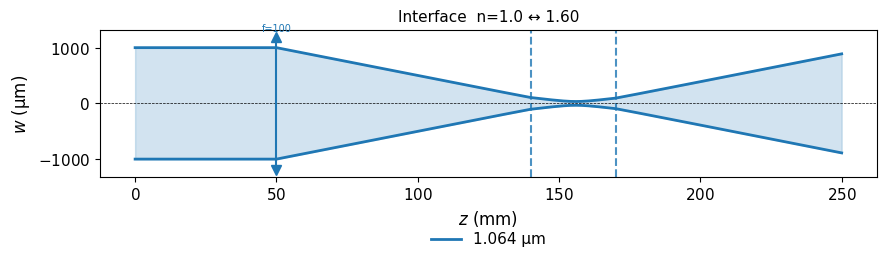

In [4]:
beam = GaussBeam.from_waist(wl_um=1.064, w0_mm=1.0)
n_crystal = 1.60
sys = (OpticalSystem()
       .add(Propagation(50))
       .add(ThinLens(f_mm=100))
       .add(Propagation(90))
       .add(Interface(n1=1.0, n2=n_crystal))
       .add(Propagation(30))
       .add(Interface(n1=n_crystal, n2=1.0))
       .add(Propagation(80)))
traj = sys.trace(beam, dz=0.5)
print(sys.summary(beam))

fig, ax = plt.subplots(figsize=(9, 3))
gplot.plot_system(sys, traj, ax, label='1.064 µm')
ax.set_title('Interface  n=1.0 ↔ 1.60')
plt.tight_layout()

## InterfaceCurved (curved refracting surface)

OpticalSystem trace  [wl=1.064 um]
   #  Type                   z (mm)     w (um)      R (mm)   th (urad)
------------------------------------------------------------------------
   0  --- input ---           0.000    1000.00         inf      338.68
   1  Propagation            80.000    1000.37   1.091e+05      338.56
   2  InterfaceCurved        80.000    1000.37   1.332e+02      211.60
   3  Propagation           120.000    1300.73   1.732e+02      162.74
   4  InterfaceCurved       120.000    1300.73   4.709e+01      260.38
   5  Propagation           200.000    3510.74   1.271e+02       96.47


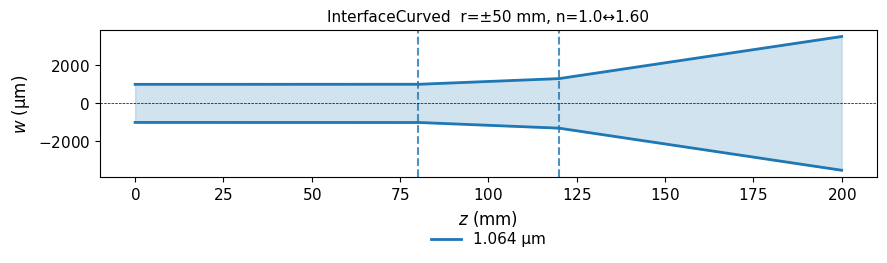

In [5]:
beam = GaussBeam.from_waist(wl_um=1.064, w0_mm=1.0)
n_crystal = 1.60
sys = (OpticalSystem()
       .add(Propagation(80))
       .add(InterfaceCurved(n1=1.0, n2=n_crystal, r_mm=50))
       .add(Propagation(40))
       .add(InterfaceCurved(n1=n_crystal, n2=1.0, r_mm=-50))
       .add(Propagation(80)))
traj = sys.trace(beam, dz=0.5)
print(sys.summary(beam))

fig, ax = plt.subplots(figsize=(9, 3))
gplot.plot_system(sys, traj, ax, label='1.064 µm')
ax.set_title('InterfaceCurved  r=±50 mm, n=1.0↔1.60')
plt.tight_layout()

## CurvedMirrorTan (tangential)

OpticalSystem trace  [wl=1.064 um]
   #  Type                   z (mm)     w (um)      R (mm)   th (urad)
------------------------------------------------------------------------
   0  --- input ---           0.000    1000.00         inf      338.68
   1  Propagation           100.000    1000.57   8.728e+04      338.49
   2  CurvedMirrorTan       100.000    1000.57  -9.859e+01      338.49
   3  Propagation           200.000      36.74   8.627e+00     9217.77
Beam waists:  z=198.490 mm (2w0=66.7 um)


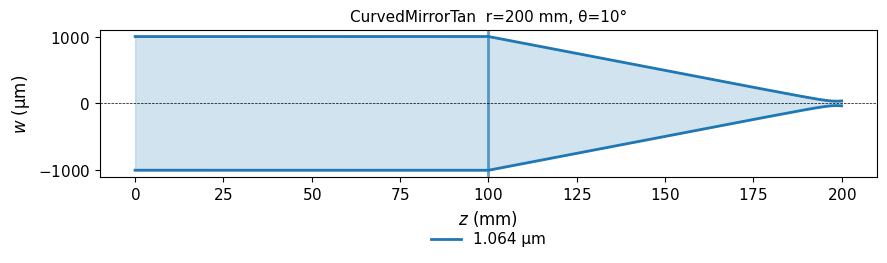

In [6]:
beam = GaussBeam.from_waist(wl_um=1.064, w0_mm=1.0)
sys = (OpticalSystem()
       .add(Propagation(100))
       .add(CurvedMirrorTan(r_mm=200, theta_deg=10))
       .add(Propagation(100)))
traj = sys.trace(beam, dz=0.5)
print(sys.summary(beam))

fig, ax = plt.subplots(figsize=(9, 3))
gplot.plot_system(sys, traj, ax, label='1.064 µm')
ax.set_title('CurvedMirrorTan  r=200 mm, θ=10°')
plt.tight_layout()

## CurvedMirrorSag (sagittal)

OpticalSystem trace  [wl=1.064 um]
   #  Type                   z (mm)     w (um)      R (mm)   th (urad)
------------------------------------------------------------------------
   0  --- input ---           0.000    1000.00         inf      338.68
   1  Propagation           100.000    1000.57   8.728e+04      338.49
   2  CurvedMirrorSag       100.000    1000.57  -1.017e+02      338.49
   3  Propagation           200.000      37.59  -9.455e+00     9009.75


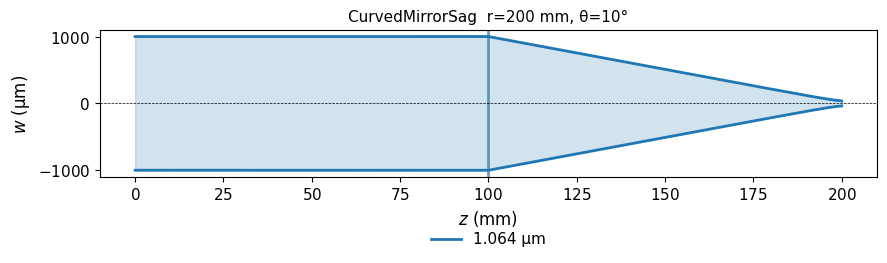

In [7]:
beam = GaussBeam.from_waist(wl_um=1.064, w0_mm=1.0)
sys = (OpticalSystem()
       .add(Propagation(100))
       .add(CurvedMirrorSag(r_mm=200, theta_deg=10))
       .add(Propagation(100)))
traj = sys.trace(beam, dz=0.5)
print(sys.summary(beam))

fig, ax = plt.subplots(figsize=(9, 3))
gplot.plot_system(sys, traj, ax, label='1.064 µm')
ax.set_title('CurvedMirrorSag  r=200 mm, θ=10°')
plt.tight_layout()

## CurvedMirrorTan vs Sag 比較（非点収差）

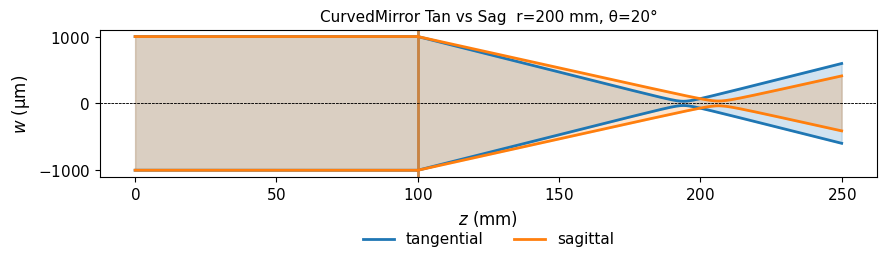

In [8]:
beam = GaussBeam.from_waist(wl_um=1.064, w0_mm=1.0)
r, theta = 200, 20

sys_tan = (OpticalSystem()
           .add(Propagation(100))
           .add(CurvedMirrorTan(r_mm=r, theta_deg=theta))
           .add(Propagation(150)))
sys_sag = (OpticalSystem()
           .add(Propagation(100))
           .add(CurvedMirrorSag(r_mm=r, theta_deg=theta))
           .add(Propagation(150)))

traj_tan = sys_tan.trace(beam, dz=0.5)
traj_sag = sys_sag.trace(beam, dz=0.5)

fig, ax = plt.subplots(figsize=(9, 3))
gplot.plot_system(sys_tan, traj_tan, ax, label='tangential')
gplot.plot_system(sys_sag, traj_sag, ax, label='sagittal')
ax.set_title(f'CurvedMirror Tan vs Sag  r={r} mm, θ={theta}°')
plt.tight_layout()